### Intsall all dependencies (Ubuntu)

###### Install these from root terminal
```bash
apt-get update > /dev/null
apt install tesseract-ocr
```

In [1]:
!pip install transformers
!pip install torch
!pip install pytesseract
!pip install timm
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


Defaulting to user installation because normal site-packages is not writeable


In [2]:
from PIL import Image, ImageDraw
from transformers import LayoutLMv3FeatureExtractor, LayoutLMv3ImageProcessor, LayoutLMv3TokenizerFast, LayoutLMv3Processor, LayoutLMv3ForSequenceClassification
import numpy as np
from transformers import DetrFeatureExtractor, DetrImageProcessor, TableTransformerForObjectDetection
import torch
import matplotlib.pyplot as plt

In [47]:
def generate_layoutlm(img: Image):
#     layoutlm_feature_extractor = LayoutLMv3FeatureExtractor(apply_ocr=True, ocr_lang="eng")
    layoutlm_image_processor =  LayoutLMv3ImageProcessor(apply_ocr=True, ocr_lang="eng")
#     layoutlm_tokenizer = LayoutLMv3TokenizerFast.from_pretrained("microsoft/layoutlmv3-base")
    layoutlm_tokenizer = LayoutLMv3TokenizerFast.from_pretrained("Mit1208/layoutlmv3-finetuned-DocLayNet")
#     layoutlm_processor = LayoutLMv3Processor(layoutlm_feature_extractor, layoutlm_tokenizer)
    layoutlm_processor = LayoutLMv3Processor(layoutlm_image_processor, layoutlm_tokenizer)
    layoutlm_processor_encoding = layoutlm_processor(
        input_image,
        max_length = 512,
        padding = "max_length",
        truncation = True,
        return_tensors = "pt"
    )
    
    return layoutlm_image_processor, layoutlm_tokenizer, layoutlm_processor, layoutlm_processor_encoding

In [48]:
def gernate_detr(img: Image):
    detr_image_processor = DetrImageProcessor()
    detr_image_processor_encoding = detr_image_processor(input_image, return_tensors="pt")
    table_detection_model = TableTransformerForObjectDetection.from_pretrained("microsoft/table-transformer-detection")
    
    with torch.no_grad():
        detr_outputs = table_detection_model(**detr_image_processor_encoding)
    
    return detr_image_processor, detr_image_processor_encoding, table_detection_model, detr_outputs

In [5]:
def get_table_cells(table_results):
    table_scores = table_results['scores'].tolist()
    table_labels = table_results['labels'].tolist()
    table_boxes = table_results['boxes'].tolist()
    
    column_scores = list()
    column_labels = list()
    column_boxes = list()
    
    row_scores = list()
    row_labels = list()
    row_boxes = list()
    
    cell_scores = list()
    cell_labels = list()
    cell_boxes = list()
    
    for idx, label in enumerate(table_labels):
        if label == 1:
            column_scores.append(table_scores[idx])
            column_labels.append(label)
            column_boxes.append(table_boxes[idx])
        elif label == 2:
            row_scores.append(table_scores[idx])
            row_labels.append(label)
            row_boxes.append(table_boxes[idx])

    for r in range(len(row_boxes)):
        r_xmin = row_boxes[r][0]
        r_ymin = row_boxes[r][1]
        r_xmax = row_boxes[r][2]
        r_ymax = row_boxes[r][3]
        for c in range(len(column_boxes)):
            c_xmin = column_boxes[c][0]
            c_ymin = column_boxes[c][1]
            c_xmax = column_boxes[c][2]
            c_ymax = column_boxes[c][3]

            n_xmin = max(r_xmin, c_xmin)
            n_ymin = max(r_ymin, c_ymin)
            n_xmax = min(r_xmax, c_xmax)
            n_ymax = min(r_ymax, c_ymax)

            cell_scores.append(0.99)
            cell_labels.append(1)
            cell_boxes.append([n_xmin, n_ymin, n_xmax, n_ymax])
            
    row_count = len(row_boxes)
    column_count = len(column_boxes)
            
    return cell_scores, cell_labels, cell_boxes, row_count, column_count

In [6]:
def center_in_box(x_center, y_center, bbox):
    x1, y1, x2, y2 = bbox
    return x1 <= x_center <= x2 and y1 <= y_center <= y2

# Frist word
def find_word(cell: list(), input_image_words: list(), input_image_bounding_boxes: list()):
    return_word = ""
    
    for idx, bbox in enumerate(input_image_bounding_boxes):
        center = ((bbox[0] + bbox[2]) / 2, (bbox[1] + bbox[3]) / 2)
        if center_in_box(center[0], center[1], cell):
            return_word = input_image_words[idx]
            input_image_words[idx] = ''
            break
        
    return return_word

In [33]:
def show_words_and_boxes(table_words: list(), cell_boxes: list(), input_image_words: list(), input_image_bounding_boxes: list()):
    COLORS = [[0.000, 0.447, 0.741], [0.850, 0.325, 0.098], [0.929, 0.694, 0.125],
              [0.494, 0.184, 0.556], [0.466, 0.674, 0.188], [0.301, 0.745, 0.933]]

    plt.figure(figsize=(16,10))
    plt.imshow(input_image.copy())
    ax = plt.gca()
    colors = COLORS * 100

    for label, (xmin, ymin, xmax, ymax), c  in zip(table_words, cell_boxes, colors):
        ax.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                   fill=False, color=c, linewidth=3))
        text = f"{label if label != '' else 'empty'}:T"
        ax.text(xmin, ymin, text, fontsize=15,
                bbox=dict(facecolor='yellow', alpha=0.5))

    for label, (xmin, ymin, xmax, ymax), c  in zip(input_image_words, input_image_bounding_boxes, colors):
        if label != '':
            ax.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                   fill=False, color=c, linewidth=3))
            text = f'{label}:NT'
            ax.text(xmin, ymin, text, fontsize=15,
                    bbox=dict(facecolor='yellow', alpha=0.5))
    plt.axis('off')
#     plt.show()

    return plt

In [8]:
def translate_image(img: Image) -> list():
    img_width, img_height = img.size
    width_scale = img_width / 1000
    height_scale = img_height / 1000
    
    x1_scale = -30
    y1_scale = -30
    x2_scale = +30
    y2_scale = +30
    
    layoutlm_image_processor, layoutlm_tokenizer, layoutlm_processor, layoutlm_processor_encoding = generate_layoutlm(img)
    detr_feature_extractor, detr_feature_extractor_encoding, table_detection_model, detr_outputs = gernate_detr(img)
    
    layoutlm_features = layoutlm_image_processor(img)
    input_image_pixel_values = layoutlm_features["pixel_values"][0]
    input_image_words = layoutlm_features["words"][0]
    input_image_bounding_boxes = layoutlm_features["boxes"][0]
    
    for bbox in input_image_bounding_boxes:
        bbox[0] = bbox[0] * width_scale
        bbox[1] = bbox[1] * height_scale
        bbox[2] = bbox[2] * width_scale
        bbox[3] = bbox[3] * height_scale
    
    results = detr_feature_extractor.post_process_object_detection(detr_outputs, threshold=0.7, target_sizes=[(img_height, img_width)])[0]
    
    if len(results['scores'].tolist()) > 0:    
        for idx, _ in enumerate(results['scores']):
            (table_xmin, table_ymin, table_xmax, table_ymax) = zip(results['boxes'][idx].tolist())
            table_image = input_image.crop((
                table_xmin[0] + x1_scale, 
                table_ymin[0] + y1_scale, 
                table_xmax[0] + x2_scale, 
                table_ymax[0] + y2_scale)
            )

            detr_table_feature_extractor_encoding = detr_feature_extractor(table_image, return_tensors="pt")
            table_structure_model = TableTransformerForObjectDetection.from_pretrained("microsoft/table-transformer-structure-recognition")
            with torch.no_grad():
                table_outputs = table_structure_model(**detr_table_feature_extractor_encoding)

            target_sizes = [table_image.size[::-1]]
            table_results = detr_feature_extractor.post_process_object_detection(table_outputs, threshold=0.6, target_sizes=target_sizes)[0]

            cell_scores, cell_labels, cell_boxes, row_count, column_count = get_table_cells(table_results)

            for cb in cell_boxes:
                cb[0] = cb[0] + table_xmin[0] + x1_scale
                cb[1] = cb[1] + table_ymin[0] + y1_scale
                cb[2] = cb[2] + table_xmin[0] + x1_scale
                cb[3] = cb[3] + table_ymin[0] + y1_scale

            table_words = list()

            for row_idx in range(row_count):
                for column_idx in range(column_count):
                    word_in_cell = find_word(cell_boxes[((row_idx * column_count) + column_idx)], input_image_words, input_image_bounding_boxes)
                    table_words.append(word_in_cell)
    else:
        table_words = list()
        cell_boxes = list()
                
    plt = show_words_and_boxes(table_words, cell_boxes, input_image_words, input_image_bounding_boxes)
                
    return table_words, cell_boxes, input_image_words, input_image_bounding_boxes, plt

In [41]:
input_image = Image.open('./assets/handwritten/IMG_3600.jpeg').convert("RGB")

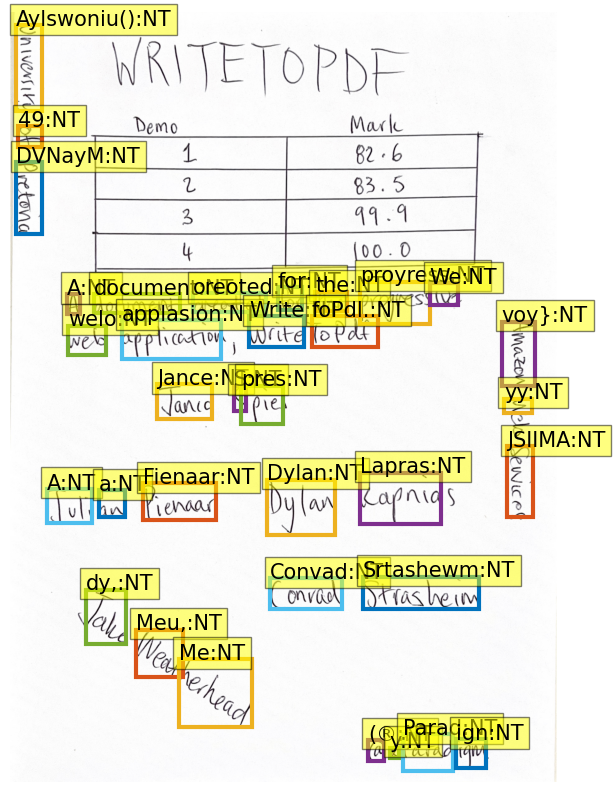

In [49]:
table_words, table_words_bounding_boxes, non_table_words, non_table_words_bounding_boxes, plt = translate_image(input_image)

In [17]:
table_words

[]